**What is covered in `experimments_1` notebook?**
- Extracting Text page-wise, block-wise, even from multi-column magazine style layout in correct reading order
- Extracting images and display opr save them page wise
- Extracting images with in-image captions

**What am I going to cover in this notebook?**

- Distinguish "Body Text" from "headers" and "footers"
- Identifying "heading", "subheading", and "section breaks"
- Detect "Page numbers", "watermarks", and "foot notes"
- Preserve "line breaks" where they matter and ignore them where they do not
- Handle rotated text or sideways annotations
- Reconstruct reading order in documents with mixed layout styles:
    - separate images + captions
    - main content text blocks with correct reading orders (with heading sub-heading etc)
    - footer notes, page no, etc
    - compare it with "to_markdown" function.
- 

In [38]:
import fitz
from pprint import pprint
from pathlib import Path
from docling.document_converter import DocumentConverter


In [39]:
fitz_pdf = fitz.open(file_path)

In [14]:
data_folder_path = Path("/mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/iid-platform/sample_data/named")
file_path = data_folder_path / "nature-alberta-spring-2026-magazine-medium-mix-multi-col-text.pdf"
file_path

PosixPath('/mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/iid-platform/sample_data/named/nature-alberta-spring-2026-magazine-medium-mix-multi-col-text.pdf')

In [15]:
converter = DocumentConverter()
doc = converter.convert(file_path).document

[INFO] 2026-04-24 17:08:17,984 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-24 17:08:18,332 [RapidOCR] download_file.py:60: File exists and is valid: /mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/.llmenv/lib/python3.10/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-04-24 17:08:18,333 [RapidOCR] main.py:53: Using /mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/.llmenv/lib/python3.10/site-packages/rapidocr/models/ch_PP-OCRv4_det_infer.onnx
[INFO] 2026-04-24 17:08:18,844 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-24 17:08:18,919 [RapidOCR] download_file.py:60: File exists and is valid: /mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/.llmenv/lib/python3.10/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer.onnx
[INFO] 2026-04-24 17:08:18,920 [RapidOCR] main.py:53: Using /mnt/c/Users/Rakesh-PC/Documents/1_GitHubSync_SSH/.llmenv/lib/python3.10/site-packages/rapidocr/models/ch_ppocr_mobile_v2.0_cls_infer

In [16]:
# doc.export_to_markdown()

In [17]:
type(doc)

docling_core.types.doc.document.DoclingDocument

In [18]:
docdict = dict(doc)
docdict

{'schema_name': 'DoclingDocument',
 'version': '1.10.0',
 'name': 'nature-alberta-spring-2026-magazine-medium-mix-multi-col-text',
 'origin': DocumentOrigin(mimetype='application/pdf', binary_hash=9295684724258981057, filename='nature-alberta-spring-2026-magazine-medium-mix-multi-col-text.pdf', uri=None),
 'furniture': GroupItem(self_ref='#/furniture', parent=None, children=[], content_layer=<ContentLayer.FURNITURE: 'furniture'>, meta=None, name='_root_', label=<GroupLabel.UNSPECIFIED: 'unspecified'>),
 'body': GroupItem(self_ref='#/body', parent=None, children=[RefItem(cref='#/texts/0'), RefItem(cref='#/pictures/0'), RefItem(cref='#/texts/5'), RefItem(cref='#/texts/6'), RefItem(cref='#/texts/7'), RefItem(cref='#/texts/8'), RefItem(cref='#/texts/9'), RefItem(cref='#/texts/10'), RefItem(cref='#/texts/11'), RefItem(cref='#/pictures/1'), RefItem(cref='#/texts/14'), RefItem(cref='#/texts/15'), RefItem(cref='#/texts/16'), RefItem(cref='#/texts/17'), RefItem(cref='#/pictures/2'), RefItem(cre

In [21]:
docdict.keys()

dict_keys(['schema_name', 'version', 'name', 'origin', 'furniture', 'body', 'groups', 'texts', 'pictures', 'tables', 'key_value_items', 'form_items', 'field_regions', 'field_items', 'pages'])

In [23]:
myset = set()
for e in docdict['texts']:  # texts pictures
    myset.add(type(e))
myset

{docling_core.types.doc.document.ListItem,
 docling_core.types.doc.document.SectionHeaderItem,
 docling_core.types.doc.document.TextItem}

**Observation :**

**docling_core.types.doc.document.DoclingDocument**

* **'schema_name'**     : 'DoclingDocument'
* **'version'**         : '1.10.0'
* **'name'**            : 'file_name_excluding_extension'
* **'origin'**          : A `DocumentOrigin` object, which contains filetype (for ex pdf, etc) under mimetype
                          key or attribute, a 19 digit integer as 'bynary_hash'
* **'furniture'**       : A `GroupItem` object, which stores parts of a document that are structural or 
                          decorative, not part of the main content
* **'body'**            : A `GroupItem` object, which has 'self_ref' as "#/body", 'parent' as None, 
                          'children' as a list of reference items (`RefItem`s), the RefItem looks like:
                          RefItem(cref='#/<`texts` or `pictures` as str>/<index or serial num: int>')
* **'groups'**            A list of `ListGroup` objects or `GroupItem` objects or mix of both. Any item or
                          element in the `DoclingDocument['groups']` list irrespective of ListGroup or 
                          GroupItem it has 'self_ref' as `"#/groups/<incremental serial num: int>"`. 
                          'parent' may be RefItem(cref='#/body') or some other item with apt ref. 
                          'children' will be a list of reference items (`RefItem`s), 'children' maybe empty
                          list in some cases.  
* **'text'**            : A list of any objects out of the following: `SectionHeaderItem`, `TextItem`, 
                          or `ListItem`.
                          Any item or element in the `DoclingDocument['texts']` list irrespective of 
                          SectionHeaderItem or TextItem or ListItem it has 'self_ref' as 
                          `"#/texts/<incremental serial num: int>"`.
                          Any of these elements may have a list of reference items (`RefItem`s) as 'children'.
                          Elements inside `DoclingDocument['texts']` have an extra attribute `prov`, 
                          which contains a list of `ProvenanceItem` objects.
                          `ProvenanceItem` contains page number (page_no), bounding box (bbox), coordinate
                          origin (coord_origin), character span (charspan), the text within this block (orig
                          or text attribute), it may contain hyperlink. In case of SectionHeaderItem it 
                          contains the section header level as integer. 
* **'pictures'**        : Contains a list of `PictureItem`s. A PictureItem element has 'self_ref' as 
                          `"#/pictures/<incremental serial num: int>"`, 'children' as a list of reference items
                          for text blocks, these text blocks are in-image captions, in 'prov' key it contains 
                          a list of `ProvenanceItem` objects and bounding box (bbox) information inside it, 
                          this bbox is for the image, the cropped portion of the pdf. 
* **'tables'**          : Empty list if no tables detected in the pdf or document. 
* **'key_value_items'** : Empty list if no key value items detected in the pdf or document.
* **'form_items'**      : Empty list if no form items detected in the pdf or document.
* **'pages'**           : A dictionary, keys are indices 1,2,3,...
                          Each index stores a PageItem containing "Size" with height and width of that page, 
                          It also stores the page number (page_no: int) of this page item as per the pdf or doc.

**What to do next?**
1. **Understand what are 'groups':** Check different group items like `ListGroup` or `GroupItem`, match with original pdf
2. **Understand different kinds of 'texts':** Check different text items like `SectionHeaderItem` or `TextItem` or `ListItem`, match with original pdf
3. Check `PictureItem`s and the ref text blocks, and match with original pdf

**Understand what are 'groups'**
- Let's examine the first group (idx 0) from the list

In [27]:
group0 = docdict['groups'][0] 
pprint(dict(group0))

{'children': [RefItem(cref='#/texts/24'),
              RefItem(cref='#/texts/25'),
              RefItem(cref='#/texts/26'),
              RefItem(cref='#/texts/27'),
              RefItem(cref='#/texts/28'),
              RefItem(cref='#/texts/29'),
              RefItem(cref='#/texts/30'),
              RefItem(cref='#/texts/31'),
              RefItem(cref='#/texts/32'),
              RefItem(cref='#/texts/33'),
              RefItem(cref='#/texts/34'),
              RefItem(cref='#/texts/35'),
              RefItem(cref='#/texts/36'),
              RefItem(cref='#/texts/37')],
 'content_layer': <ContentLayer.BODY: 'body'>,
 'label': <GroupLabel.LIST: 'list'>,
 'meta': None,
 'name': 'list',
 'parent': RefItem(cref='#/body'),
 'self_ref': '#/groups/0'}


In [28]:
# Let's print the text content from each of these `RefItem`s and also in the original pdf 
# to explore why these blocks are kept in the same group.

In [42]:
# list of integers of the text blocks for group with index 0
blocksidx = list(range(24, 38))
# make the 'texts' list to dict with the text block idx as key
textblocks = {}  # key=block_index ; value=tuple(page_no, text_content)
for ele in docdict['texts']:
    blockidx = int(list(ele.self_ref.split('/'))[-1])
    # textblocks dict :: key=block_index ; value=tuple(page_no, text_content)
    textblocks[blockidx] = tuple([ele.prov[0].page_no, ele.text])
# Print the targeted blocks under group 0
print("Printing for group 0 : This is a ListGroup object")
print(f"Involved block indices are: {blocksidx}\n")
for idx in blocksidx:
    print(f"Idx: {idx}  |  PageNo: {textblocks[idx][0]}  |  Text: {textblocks[idx][1]}")

Printing for group 0 : This is a ListGroup object
Involved block indices are: [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]

Idx: 24  |  PageNo: 3  |  Text: 2 President's Message
Idx: 25  |  PageNo: 3  |  Text: 3 Nature Alberta News
Idx: 26  |  PageNo: 3  |  Text: 4 Caribou Update: Plans for Extirpation
Idx: 27  |  PageNo: 3  |  Text: 6 A Hummingbird Primer
Idx: 28  |  PageNo: 3  |  Text: 11 Of Tree Rings and Tea Leaves
Idx: 29  |  PageNo: 3  |  Text: 14 Botanical Treasures of Hinton's Beaver Boardwalk
Idx: 30  |  PageNo: 3  |  Text: 18 Coal Confusion: Throwing Dust in the Air
Idx: 31  |  PageNo: 3  |  Text: 23 Book Review: Frank Farley and the Birds of Alberta
Idx: 32  |  PageNo: 3  |  Text: 24 Sharing Space: For the Love of Honkers
Idx: 33  |  PageNo: 3  |  Text: 25 Your Shot
Idx: 34  |  PageNo: 3  |  Text: 26 Disappearing Peace: The Mountain Meadows of Alberta's Rockies
Idx: 35  |  PageNo: 3  |  Text: 32 Spring Spawn: Northern Pike and Walleye
Idx: 36  |  PageNo: 3  |  Te

**Comment:**

- In the original pdf doc this is the contents, which is a group of text elements
- This was a ListGroup object, let's check the next group elements (idx 1 and 2), which are GroupItem objects.
- There is no children in groups index 1, so only idx 2 will be examined

In [41]:
group1 = docdict['groups'][1]
group2 = docdict['groups'][2]
pprint(dict(group1))
print()
pprint(dict(group2))

{'children': [],
 'content_layer': <ContentLayer.BODY: 'body'>,
 'label': <GroupLabel.KEY_VALUE_AREA: 'key_value_area'>,
 'meta': None,
 'name': 'group',
 'parent': RefItem(cref='#/body'),
 'self_ref': '#/groups/1'}

{'children': [RefItem(cref='#/texts/47'),
              RefItem(cref='#/texts/48'),
              RefItem(cref='#/texts/49'),
              RefItem(cref='#/texts/50'),
              RefItem(cref='#/texts/51'),
              RefItem(cref='#/texts/52'),
              RefItem(cref='#/texts/53'),
              RefItem(cref='#/texts/54'),
              RefItem(cref='#/texts/55'),
              RefItem(cref='#/texts/56'),
              RefItem(cref='#/texts/57')],
 'content_layer': <ContentLayer.BODY: 'body'>,
 'label': <GroupLabel.KEY_VALUE_AREA: 'key_value_area'>,
 'meta': None,
 'name': 'group',
 'parent': RefItem(cref='#/body'),
 'self_ref': '#/groups/2'}


In [43]:
# list of integers of the text blocks for group with index 2
blocksidx = list(range(47, 58))
# make the 'texts' list to dict with the text block idx as key
textblocks = {}  # key=block_index ; value=tuple(page_no, text_content)
for ele in docdict['texts']:
    blockidx = int(list(ele.self_ref.split('/'))[-1])
    # textblocks dict :: key=block_index ; value=tuple(page_no, text_content)
    textblocks[blockidx] = tuple([ele.prov[0].page_no, ele.text])
# Print the targeted blocks under group 0
print("Printing for group idx 2 : This is a GroupItem object")
print(f"Involved block indices are: {blocksidx}\n")
for idx in blocksidx:
    print(f"Idx: {idx}  |  PageNo: {textblocks[idx][0]}  |  Text: {textblocks[idx][1]}")

Printing for group idx 2 : This is a GroupItem object
Involved block indices are: [47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57]

Idx: 47  |  PageNo: 4  |  Text: Publisher Nature Alberta
Idx: 48  |  PageNo: 4  |  Text: Executive Director
Idx: 49  |  PageNo: 4  |  Text: Stephanie Weizenbach
Idx: 50  |  PageNo: 4  |  Text: Editor-in-Chief Erin McCloskey
Idx: 51  |  PageNo: 4  |  Text: Managing Editor Jason Switner
Idx: 52  |  PageNo: 4  |  Text: Creative Susan May, intrinsic design
Idx: 53  |  PageNo: 4  |  Text: Cover Image Myrna Pearman
Idx: 54  |  PageNo: 4  |  Text: Nature Alberta Magazine is published four times per year by:
Idx: 55  |  PageNo: 4  |  Text: Nature Alberta 11759 Groat Road Edmonton, AB  T5M 3K6 (780) 427-8124
Idx: 56  |  PageNo: 4  |  Text: info@naturealberta.ca
Idx: 57  |  PageNo: 4  |  Text: Content editorinchief@naturealberta.ca


**Comment:**
- This was another group of text blocks from page 4

**Understand different kinds of 'texts'**
- Few `SectionHeaderItem`s are : [ `self_ref='#/texts/0'`, `self_ref='#/texts/70'` ]
- Few `TextItem`s are : [ `self_ref='#/texts/1'`, `self_ref='#/texts/60'`, `self_ref='#/texts/68'` ]
- Few `ListItem`s are : [ `self_ref='#/texts/214'`, `self_ref='#/texts/215'`, `self_ref='#/texts/216'` ]

In [44]:
# SectionHeaderItem
indices = [0, 70]
for idx in indices:
    print(f"Idx: {idx}  |  PageNo: {textblocks[idx][0]}  |  Text: {textblocks[idx][1]}")

Idx: 0  |  PageNo: 1  |  Text: NATURE ALBERTA
Idx: 70  |  PageNo: 4  |  Text: PRESIDENT'S MESSAGE


In [45]:
# TextItem
indices = [1, 60, 68]
for idx in indices:
    print(f"Idx: {idx}  |  PageNo: {textblocks[idx][0]}  |  Text: {textblocks[idx][1]}")

Idx: 1  |  PageNo: 1  |  Text: SPRING 2026
Idx: 60  |  PageNo: 4  |  Text: Nature Alberta Magazine (electronic) is made available free of charge at naturealberta.ca . Print copies of Nature Alberta Magazine are available by annual subscription for $32 (Canadian funds + GST), which covers four issues per year, plus postage and handling, within Canada. Subscriptions can be purchased at naturealberta.ca/store . Publications Mail Agreement No. 40015475
Idx: 68  |  PageNo: 4  |  Text: LOVE OF NATURE


In [47]:
# ListItem
indices = [214, 215, 216]
for idx in indices:
    print(f"Idx: {idx}  |  PageNo: {textblocks[idx][0]}  |  Text: {textblocks[idx][1]}")

Idx: 214  |  PageNo: 7  |  Text:  Environment and Climate Change Canada (2020). Agreement for the conservation and recovery of the Woodland Caribou in Alberta. canada. ca/en/environment-climate-change/ services/species-risk-public-registry/ conservation-agreements/agreementconservation-woodland-caribouboreal-alberta-2020.html
Idx: 215  |  PageNo: 7  |  Text:  Environment Canada (2012). Recovery Strategy for the Woodland Caribou (Rangifer tarandus caribou), Boreal population, in Canada. publications.gc.ca/ collections/ collection_2012/ ec/En3-4140-2012-eng.pdf
Idx: 216  |  PageNo: 7  |  Text:  Government of Alberta (2011). A Woodland Caribou Policy for Alberta. open.alberta.ca/publications/ 9780778594789


**Comments:**
- `SectionHeaderItem`s are just normal headings/subheadings
- `TextItem`s are normal text blocks without any other identity
- But `ListItem`s are something special. The ListItems with text block indices 214, 215, and 216 are actual list item elements under "References" at page 7, each text block is a list item, and total of 3 references given at page 7. In these elements parent is given as "#/groups/7", so these kind of things are stored at text block level under `'texts'` and also at group level under `'groups'`, and also connection exist in the `parent` of each individual text block. 

- check for different levels out of all the SectionHeaderItem text blocks
- where are footers and etc

In [48]:
# loop through all the 'texts' list elements
# print all the SectionHeaderItem, their self ref, page num, text, level
from docling_core.types.doc.document import SectionHeaderItem

In [49]:
for item in docdict['texts']:
    if isinstance(item, SectionHeaderItem):
        self_ref = item.self_ref
        page_no = item.prov[0].page_no if item.prov else None
        text = item.text
        level = item.level
        print(f"self_ref: {self_ref}  |  page_no: {page_no}  |  level: {level}  |  text: {text}")


self_ref: #/texts/0  |  page_no: 1  |  level: 1  |  text: NATURE ALBERTA
self_ref: #/texts/14  |  page_no: 2  |  level: 1  |  text: It's an Alberta thing.
self_ref: #/texts/22  |  page_no: 3  |  level: 1  |  text: CONTENTS
self_ref: #/texts/23  |  page_no: 3  |  level: 1  |  text: SPRING 2026
self_ref: #/texts/45  |  page_no: 4  |  level: 1  |  text: NATURE ALBERTA MAGAZINE
self_ref: #/texts/63  |  page_no: 4  |  level: 1  |  text: About Nature Alberta
self_ref: #/texts/70  |  page_no: 4  |  level: 1  |  text: PRESIDENT'S MESSAGE
self_ref: #/texts/78  |  page_no: 4  |  level: 1  |  text: NATURE ALBERTA BOARD OF DIRECTORS
self_ref: #/texts/97  |  page_no: 5  |  level: 1  |  text: Nature Alberta News
self_ref: #/texts/99  |  page_no: 5  |  level: 1  |  text: Proposed Tundra Swan Hunt
self_ref: #/texts/105  |  page_no: 5  |  level: 1  |  text: Contribute to Citizen Science
self_ref: #/texts/107  |  page_no: 5  |  level: 1  |  text: City Nature Challenge
self_ref: #/texts/110  |  page_no: 

**Observations:**

- only level=1 is detected, different levels are not detected

- Footer information, etc are given in the 'texts' list TextItems (maybe other items also) `content_layer` and `label` attribute

In [50]:
from docling_core.types.doc.document import ContentLayer, DocItemLabel

In [55]:
labels_set = set()
for item in docdict['texts']:
    is_furniture = item.content_layer == ContentLayer.FURNITURE
    is_not_plain_text = item.label != DocItemLabel.TEXT
    
    # if is_furniture or is_not_plain_text:
    if is_furniture:
        page_no = item.prov[0].page_no if item.prov else None
        print(f"self_ref: {item.self_ref} | type: {type(item).__name__} | label: {item.label.value} | layer: {item.content_layer.value} | page: {page_no} | text: {item.text}")
        labels_set.add(item.label.value)
        # print("-" * 50)
print()
print(labels_set)

self_ref: #/texts/11 | type: TextItem | label: page_footer | layer: furniture | page: 1 | text: PM40015475
self_ref: #/texts/43 | type: TextItem | label: page_footer | layer: furniture | page: 3 | text: NATURE ALBERTA MAGAZINE SPRING 2026
self_ref: #/texts/44 | type: TextItem | label: page_footer | layer: furniture | page: 3 | text: 1
self_ref: #/texts/84 | type: TextItem | label: page_footer | layer: furniture | page: 4 | text: Calgary:
self_ref: #/texts/85 | type: TextItem | label: page_footer | layer: furniture | page: 4 | text: Greg Appleyard
self_ref: #/texts/86 | type: TextItem | label: page_footer | layer: furniture | page: 4 | text: Central:
self_ref: #/texts/88 | type: TextItem | label: page_footer | layer: furniture | page: 4 | text: Edmonton:
self_ref: #/texts/90 | type: TextItem | label: page_footer | layer: furniture | page: 4 | text: North:
self_ref: #/texts/91 | type: TextItem | label: page_footer | layer: furniture | page: 4 | text: Heather Stocking
self_ref: #/texts/92

**Observation:**

- This is detecting some unnecessary text elements as footers
- One common pattern that I noticed: take last 2 footer elements from each page, when there are more than 2 footer elements, because, actual footer and page no combines two elements, rest above these text elements can be ignored from footers
- text block sequence will be decided by `self_ref` attribute

**PROGRESS TILL NOW:**

- explored: 'groups', 'text'
- explored: Section Headers, Footers, GroupItems, ListItems, etc

**WHAT IS DUE..!!**

- Section Breaks, Line Breaks (only where they matter), Watermarks,
- Handling Rotated Text or Sideways annotations: (! already observed that rotated texts are handled as plain text, but not sure about sideways annotations)
- 

### **Next Todo:**

- Explore images and in-image captions as done in previous notebook, make a proper function out of it (if relavant)
- Reconstruct reading order in documents with mixed layout styles:
    - separate images + captions
    - main content text blocks with correct reading orders (with heading sub-heading etc)
    - footer notes, page no, etc
    - compare it with "to_markdown" function.

So, basically collect pictures and associated in-picture captions in one variable, re-arranged main content block as another variable

Later these will go to separate pipelines

**Notes (for accurate rendering of images):**
- Docling uses a bottom-left coordinate origin, while PyMuPDF uses top-left.
- Coordinates are transformed internally to match PyMuPDF's system.


In [57]:
from docling_core.types.doc.document import PictureItem

In [69]:
def render_picture(
        picitem: PictureItem, 
        pdf: fitz.Document,
        zoom:int = 2
    ) -> fitz.Pixmap:
    """
    Render a cropped image from a PDF page based on a Docling PictureItem.
    This function extracts the region of a PDF corresponding to the bounding box stored in a PictureItem 
    and renders it as a raster image.
    Args:
        picitem (PictureItem):
            A Docling PictureItem containing provenance data with page number and bounding box coordinates.
        pdf (fitz.Document):
            An open PyMuPDF PDF document.
        zoom (int, optional):
            Scaling factor for rendering resolution. Default is 2.0.
    Returns:
        fitz.Pixmap:
            A rasterized image (Pixmap) of the clipped region.
    """
    # Convert 1-based page number → 0-based
    page_no = picitem.prov[0].page_no - 1
    page = pdf[page_no]
    
    bbox = picitem.prov[0].bbox
    page_height = page.rect.height

    # Coordinate transform (BOTTOMLEFT → TOPLEFT)
    x0 = bbox.l
    x1 = bbox.r
    y0 = page_height - bbox.t
    y1 = page_height - bbox.b

    rect = fitz.Rect(x0, y0, x1, y1)

    mat = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=mat, clip=rect)

    return pix

**3 approaches of image format**

- (1) Pixmap, (2) bytes, and (3) PIL
- **(1) Pixmap (`fitz.Pixmap`):**
    - What? : Native PyMuPDF image object
    - Pros:
        - Fast (no conversion)
        - Directly from PDF rendering
        - Can save easily
    - Cons:
        - Not very flexible
        - Limited image processing tools
    - Code (Save to file):
        ```python
        # picitem: PictureItem ; pdf: fitz.Document
        pix = render_picture(picitem, pdf)
        pix.save("output.png")      # PNG
        pix.save("output.jpg")      # JPEG (if supported)
        ```
- **(2) bytes (`pix.tobytes("png")`):**
    - What? : Raw encoded image (PNG/JPEG)
    - Pros:
        - Easy to send over network
        - Store in DB / APIs
        - Lightweight transport format
    - Cons:
        - Not directly editable
        - Need decoding to manipulate
    - Code (Save to file):
        ```python
        # picitem: PictureItem ; pdf: fitz.Document
        pix = render_picture(picitem, pdf)
        # Convert to bytes
        img_bytes = pix.tobytes("png")
        # save to file
        with open("output.png", "wb") as f:
            f.write(img_bytes)
        ```
- **(3) PIL Image (`Pillow`):**
    - What? : Full Python image object
    - Pros:
        - Rich processing: crop, resize, draw, filters, etc
        - Easy visualization (Jupyter etc.)
    - Cons:
        - Conversion overhead
        - Slightly slower
    - Code:
        - Convert from Pixmap -> bytes -> PIL => Save
            ```python
            from PIL import Image
            import io
            # PIL image
            img = Image.open(io.BytesIO(pix.tobytes("png")))
            ```
        - Save PIL image
            ```python
            # Save PIL image
            img.save("output.png")
            img.save("output.jpg", quality=95)
            ```
        - Display PIL image
            ```python
            # Python's default image viewer
            img.show()
            # In notebook
            from IPython.display import display
            display(img)
            ```
            \
            Optional (modify PIL image before saving):

            ```python
            img = img.resize((300, 300))
            img = img.convert("L")  # grayscale (if needed)
            img.save("processed.png")
            ```

**Conversion flow**
```text
Pixmap  →  bytes  →  PIL Image
   ↓          ↓         ↓
fastest   portable   flexible
```

In [70]:
from PIL import Image
import io
from IPython.display import display

from typing import Iterable, Optional, Union, Dict, Any
from docling_core.types.doc.document import PictureItem

In [76]:
def get_caption(picitem, docdict):
    texts = []
    for child in picitem.children:
        idx = int(child.cref.split('/')[-1])
        # texts.append(docdict['texts'][idx]['text'])  # TypeError: 'TextItem' object is not subscriptable
        texts.append(docdict['texts'][idx].text)
    return " ".join(texts)

In [77]:
def display_page_pictures_with_captions(
    docdict: Dict[str, Any],
    pdf: fitz.Document,
    page_no: Optional[int] = None,
    picture_refs: Optional[Iterable[str]] = None,
    zoom: float = 2.0,
) -> None:
    """
    Display images (PictureItems) from a document along with their captions.
    Pictures can be filtered either:
    - by page number (`page_no`)
    - by specific picture references (`picture_refs`, e.g. ["#/pictures/0"])
    If both filters are provided, a picture is displayed if it matches either.
    
    Args:
        docdict (Dict[str, Any]):
            Dictionary-like structure containing document items, including
            a 'pictures' list of PictureItem objects.
        pdf (fitz.Document):
            Open PyMuPDF document used for rendering images.
        page_no (Optional[int], optional):
            1-based page number to filter pictures. If None, no page filtering is applied.
        picture_refs (Optional[Iterable[str]], optional):
            Collection of picture self_ref strings to filter specific images.
            Example: ["#/pictures/0", "#/pictures/2"]
        zoom (float, optional):
            Scaling factor for rendering resolution. Default is 2.0.
    
    Returns:
        None:
            Displays images and prints captions inline.
    """
    pictures = docdict.get("pictures", [])

    for picitem in pictures:
        if not isinstance(picitem, PictureItem):
            continue

        # --- Filtering logic ---
        match_page = (
            page_no is not None
            and picitem.prov
            and picitem.prov[0].page_no == page_no
        )

        match_ref = (
            picture_refs is not None
            and picitem.self_ref in picture_refs
        )

        # If filters exist, require match
        if page_no is not None or picture_refs is not None:
            if not (match_page or match_ref):
                continue

        # --- Render image ---
        pix = render_picture(picitem, pdf, zoom=zoom)

        img = Image.open(io.BytesIO(pix.tobytes("png")))
        display(img)

        # --- Caption ---
        caption = get_caption(picitem, docdict)

        print("Caption:", caption if caption else "[No caption]")
        print(f"Displayed: {picitem.self_ref}\n")

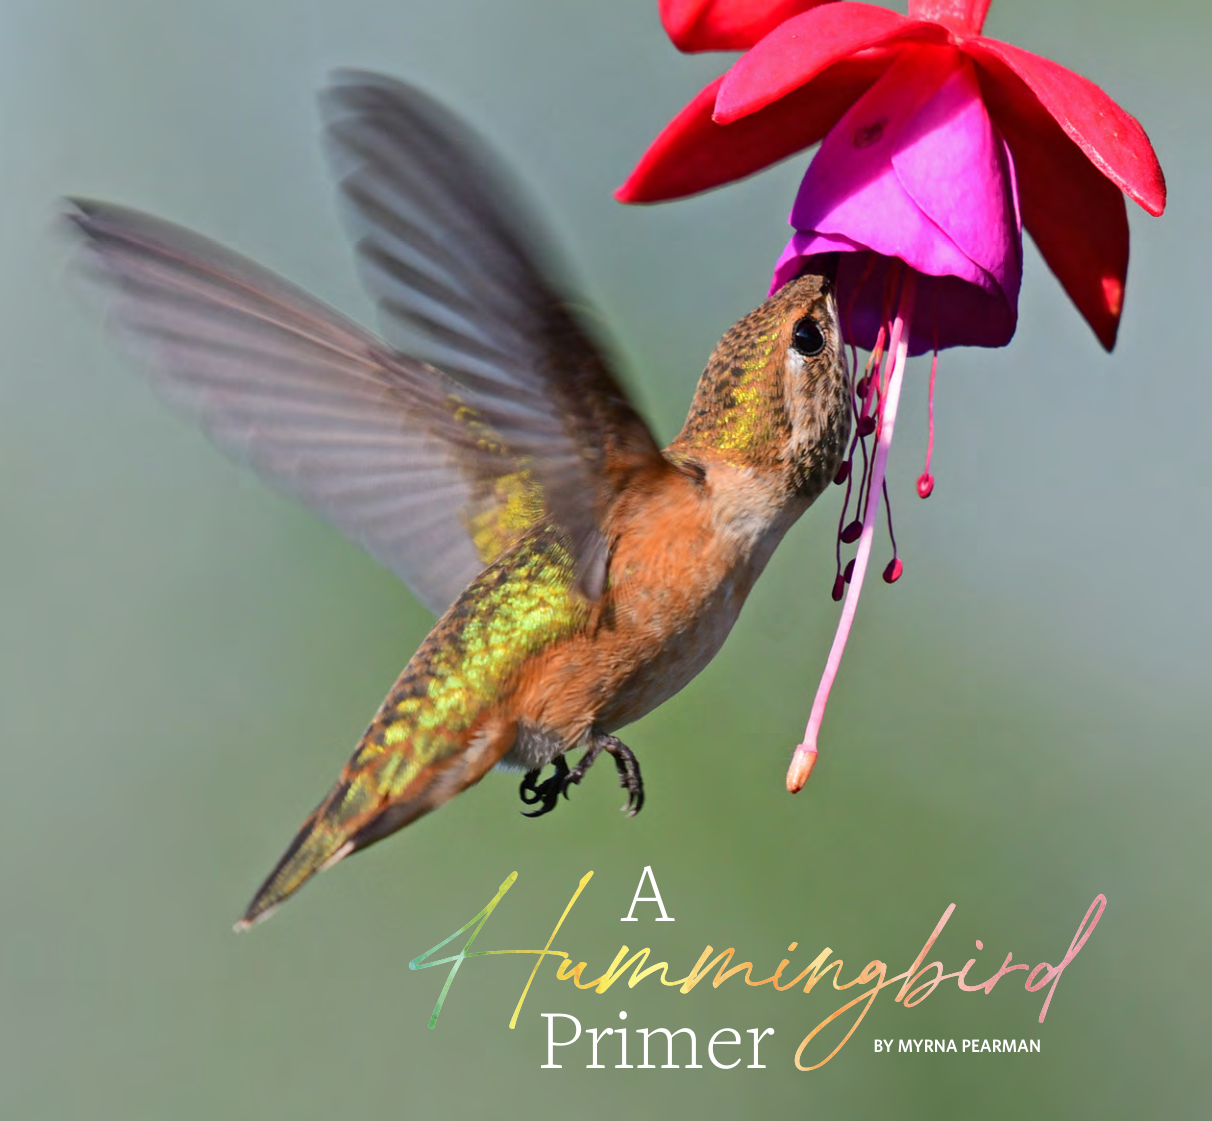

Caption: BY MYRNA PEARMAN A Primer
Displayed: #/pictures/16



In [78]:
display_page_pictures_with_captions(docdict, fitz_pdf, page_no=8)

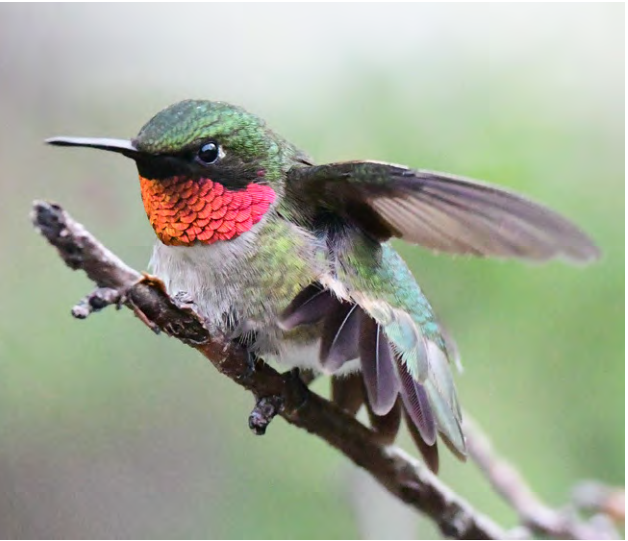

Caption: Hummingbirds often urinate while hovering, as this juvenile male rufous demonstrates.  MYRNA PEARMAN
Displayed: #/pictures/20



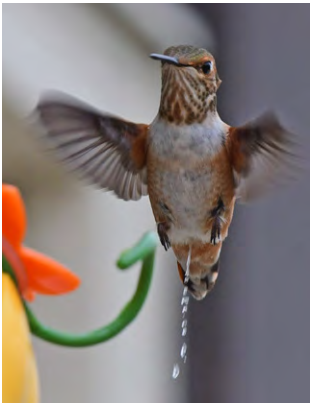

Caption: [No caption]
Displayed: #/pictures/21



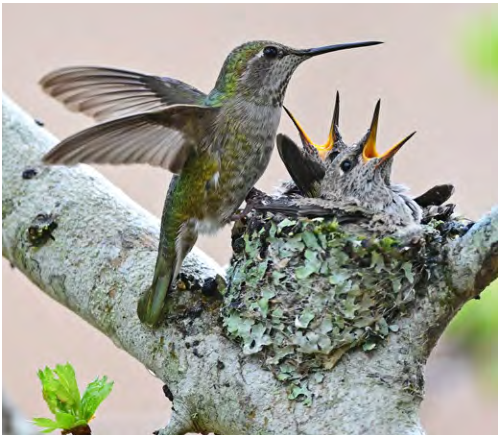

Caption: Left: An adult male ruby-throated hummingbird at rest, enjoying a good stretch and flaunting his bright gorget. MYRNA PEARMAN Above: Female hummingbirds, like this adult Anna's hummingbird, work tirelessly to feed their hungry nestlings. MYRNA PEARMAN
Displayed: #/pictures/22



In [81]:
display_page_pictures_with_captions(docdict, fitz_pdf, page_no=10)

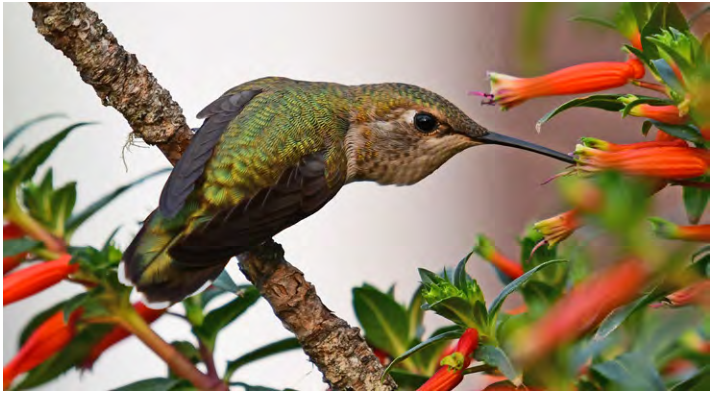

Caption: Top: An adult female rufous hummingbird takes advantage of an adjacent perch to sit on while feeding on flowers of the Cuphea genus. MYRNA PEARMAN
Displayed: #/pictures/23



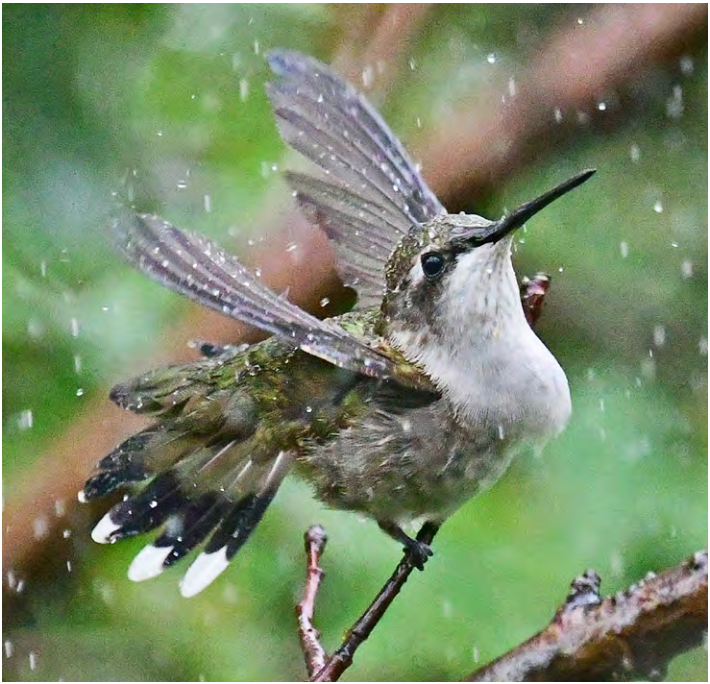

Caption: [No caption]
Displayed: #/pictures/24



In [82]:
display_page_pictures_with_captions(docdict, fitz_pdf, page_no=11)

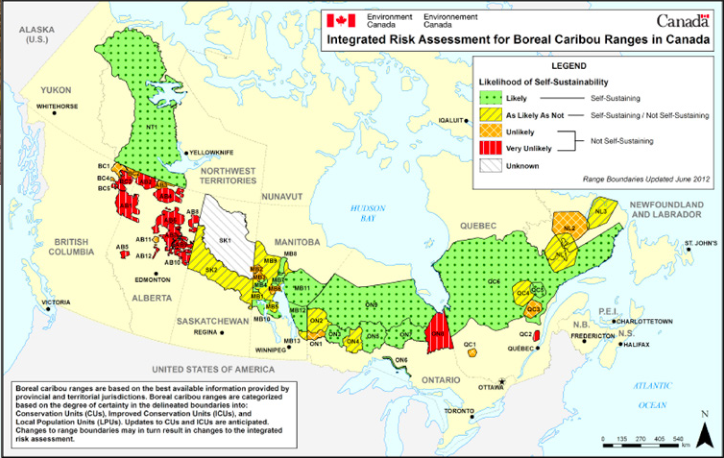

Caption: Environment Envinonnement Canada ALASKA Canada Canada (U.S.) IntegratedRiskAssessmentforBorealCaribouRangesinCanada LEGEND Likelihood of Self-Sustainability YUKON Likely Selr-Sustaining WHITEHORSE IQALUITO As Likely As Not Selif-Sustaining / Not Self-Sustaining Unlikely Not Self-Sustining YELLOWKNIFE Very Unlikely BC4A BC! TERRITORIES NORTHWEST Unknown Range Boundavies Updiated June 2012 BCS NUNAVUT HUDSON BAY QUEBEC NEWFOUNDLAND ANDLABRADOR BRITISH MANITOBA S.NHOIS COLUMBIA EDMONTON AB12 BW NCTORIA ALBERTA P.E.1. SASKATCHEWAN N.B. CHARLOTTETOWN REGINA. FREDERICTON.N.S. WINNIPEG? MB13 QUEBEC HALIFAX UNITED STATES OFAMERICA Boreal caribouranges are based on thebest available information provided by ONTARIO ATLANTIC provincialand territorialjurisdictions.Boreal caribouranges are categorized OCEAN Conservation Units (CUs),Improved Conservation Units (ICUs),and Local Population Units (LPUs). Updates to CUs and ICUs are anticipated. Changestorangeboundariesmayinturnresult inchanges

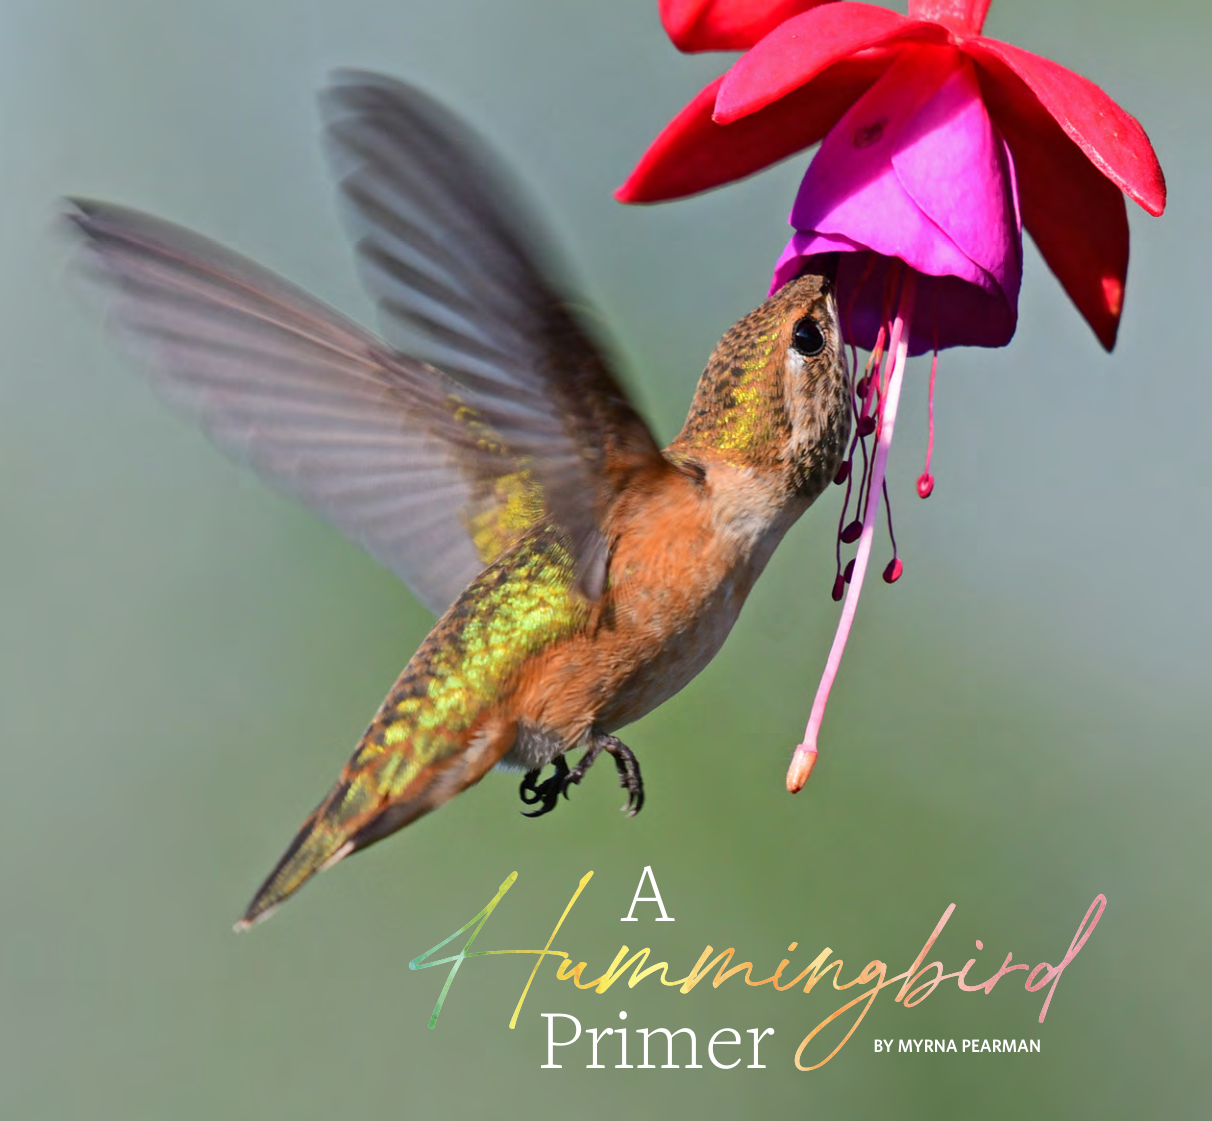

Caption: BY MYRNA PEARMAN A Primer
Displayed: #/pictures/16



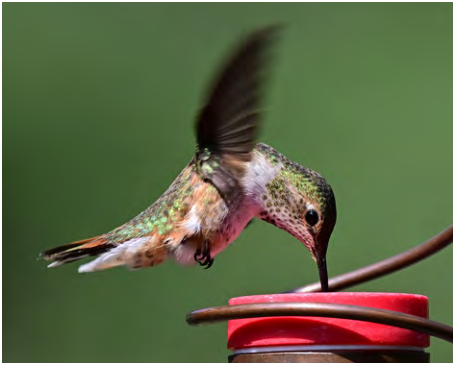

Caption: [No caption]
Displayed: #/pictures/17



In [80]:
# pic item 15 16 17
picture_refs = [f"#/pictures/{idx}" for idx in [15,16,17]]
display_page_pictures_with_captions(docdict, fitz_pdf, picture_refs=picture_refs)

**Next I want to check**

- is there any group which has text and picture reference idx both in a same group?

In [83]:
some_group = docdict['groups'][2]
pprint(dict(some_group))

{'children': [RefItem(cref='#/texts/47'),
              RefItem(cref='#/texts/48'),
              RefItem(cref='#/texts/49'),
              RefItem(cref='#/texts/50'),
              RefItem(cref='#/texts/51'),
              RefItem(cref='#/texts/52'),
              RefItem(cref='#/texts/53'),
              RefItem(cref='#/texts/54'),
              RefItem(cref='#/texts/55'),
              RefItem(cref='#/texts/56'),
              RefItem(cref='#/texts/57')],
 'content_layer': <ContentLayer.BODY: 'body'>,
 'label': <GroupLabel.KEY_VALUE_AREA: 'key_value_area'>,
 'meta': None,
 'name': 'group',
 'parent': RefItem(cref='#/body'),
 'self_ref': '#/groups/2'}


In [86]:
textonlyflag = True
for group in docdict['groups']:
    ref_item_type = set()
    for refitem in group.children:
        ref_item_type.add(refitem.cref.split('/')[1])
    if len(ref_item_type) == 0:
        print(f"Warning: Group with self_ref: {group.self_ref} has No children")
    elif len(ref_item_type) == 1:
        if textonlyflag:
            print(f"group self_ref: {group.self_ref} | ref_item_type: {list(ref_item_type)}")
            textonlyflag = False
    elif len(ref_item_type) > 1:
        print(f"group self_ref: {group.self_ref} | ref_item_type: {list(ref_item_type)}")

group self_ref: #/groups/0 | ref_item_type: ['texts']


**Observation:**

- There is no group that groups text and image blocks together

**Current Status:**

- Have a compact function to pagewise or elementwise display or save images
- It is possible to detect text blocks in a group, the text blocks in a group can be list items of an actual list hierarchy in the original document.
- It is possible to detect what text block is heading or footer or just text

**Limitations / Further works to do:**

- not all the captions are coming properly with expected images, or sometimes caption written at the end of two images and caption starts with "Top" or "above" or "left" etc keyword to represent or direct to the image whose caption is it
- these need to be detected with the help of ml separately